<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')
import torch.nn.functional as F

#It sets the output format of Matplotlib plots in Jupyter/IPython notebooks to SVG (Scalable Vector Graphics) instead of the default PNG.


from torch.utils.data import TensorDataset, DataLoader

import numpy as np


<ipython-input-3-d596777a1555>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


🧠 Why Use cos(th) and sin(th)?
These are parametric equations for a circle in 2D space:

𝑥
=
𝑟
⋅
cos
⁡
(
𝜃
)
𝑦
=
𝑟
⋅
sin
⁡
(
𝜃
)
x=r⋅cos(θ)
y=r⋅sin(θ)
θ (theta) is the angle in radians

r is the radius of the circle

When you vary θ from 0 to 2π, the point (x, y) traces a circle.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

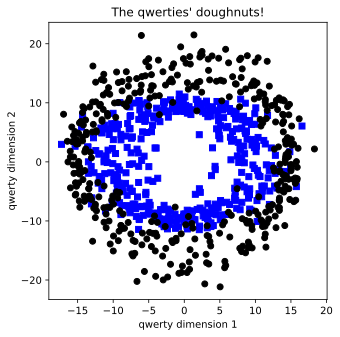

In [106]:
no_of_dp= 400

# np.linspace() is a very commonly used function in NumPy for generating evenly spaced values over a specified range.
theta = np.linspace(0, 4*np.pi, no_of_dp)
r1=10
r2=15


# first circle

# a=[r1*np.cos(theta)+np.random.randn(no_of_dp)*3,
#    r1*np.sin(theta)+np.random.randn(no_of_dp)

#    ]
# b=[r2*np.cos(theta)+np.random.randn(no_of_dp),r2*np.sin(theta)+np.random.randn(no_of_dp)*3]

# generate data
a = [ r1*np.cos(theta) + np.random.randn(no_of_dp)*3 ,
      r1*np.sin(theta) + np.random.randn(no_of_dp) ]
b = [ r2*np.cos(theta) + np.random.randn(no_of_dp) ,
      r2*np.sin(theta) + np.random.randn(no_of_dp)*3 ]

#np.zeros((nPerClust, 1))
#That means:

#“Create a 2D array with nPerClust rows and 1 column”

labels = np.vstack((np.zeros((no_of_dp,1)),np.ones((no_of_dp,1))))
data= np.hstack((a,b)).T

data = torch.tensor(data).float()
labels = torch.tensor(labels).float()




fig= plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0], 0], data[np.where(labels==0)[0], 1], 'bs') # b= blue and s=square
plt.plot(data[np.where(labels==1)[0], 0], data[np.where(labels==1)[0], 1], 'ko')# k = black and o= circle
plt.title("The qwerties' doughnuts!")
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [107]:
data.shape

torch.Size([800, 2])

In [108]:
data.shape

torch.Size([800, 2])

the dataset is created , now with split the data

In [109]:
from sklearn.model_selection import train_test_split

In [110]:
X_train,x_test,y_train,y_test= train_test_split(data, labels, test_size=0.2)

In [111]:
X_train.shape

torch.Size([640, 2])

In [112]:
X_train_tensor = TensorDataset(X_train,y_train)
X_test_tensor = TensorDataset(x_test,y_test)

In [113]:
x_y_loader_train= DataLoader(X_train_tensor, batch_size=32,shuffle=True,drop_last= True)

In [114]:
x_y_loader_test= DataLoader(X_test_tensor, batch_size=32,shuffle=True,drop_last= True)

In [115]:
X_train

tensor([[ -9.2749, -13.3427],
        [ -2.6447, -10.2079],
        [ -8.2453,   4.3698],
        ...,
        [ -0.9683,  -9.7201],
        [ 16.1620,   7.2922],
        [ -4.8287,  -8.8475]])

In [116]:
len(x_y_loader_train)

20

In [117]:
#x[21] accesses the 22nd sample in the batch (Python is zero-indexed)

[x[31] for x,y in x_y_loader_train]# x[32] accesses the 32nd sample in the batch (Python is zero-indexed)

[tensor([-5.9942,  0.2460]),
 tensor([-12.5407,  -7.6040]),
 tensor([-15.3039,  -3.5370]),
 tensor([-7.0019,  9.9603]),
 tensor([ -5.2659, -13.0401]),
 tensor([-11.2926, -10.2168]),
 tensor([-11.8998,   9.5229]),
 tensor([  3.0734, -15.6385]),
 tensor([-6.6981, 14.1046]),
 tensor([-4.9835, 16.1114]),
 tensor([0.6727, 9.3415]),
 tensor([ 8.0972, -6.8446]),
 tensor([ 14.1378, -10.7811]),
 tensor([8.5880, 9.9414]),
 tensor([7.8342, 2.3837]),
 tensor([  2.8828, -20.6583]),
 tensor([16.0001,  2.3104]),
 tensor([-10.5575,   4.6461]),
 tensor([ -8.9232, -10.7599]),
 tensor([-7.4396,  3.9964])]

In [134]:
len(x_y_loader_train)

20

In [118]:
#first batch
[x.shape[0] for x,y in x_y_loader_train][0]

32

In [76]:
class Neural_Network(nn.Module):
  def __init__(self, dropout=0):
    super().__init__()

    self.layer1= nn.Linear(2,128)
    self.hidden =nn.Linear(128,60)
    self.output=nn.Linear(60,1)
    self.dropout = dropout


  def forward(self,x):
    x= torch.relu(self.layer1(x))
    x= F.dropout(x, p=self.dropout, training = self.training)
    x= torch.relu(self.hidden(x))
    x= F.dropout(x, p=self.dropout, training = self.training)
    x= self.output(x)

    return x



def create_model(dropoutRate=0):
    model = Neural_Network(dropout= dropoutRate)
    Loss = nn.BCELoss()
    optimizer= torch.optim.Adam(model.parameters(), lr=0.001)
    return model,Loss, optimizer








In [120]:
model = Neural_Network(0.2)

In [121]:

x= torch.tensor(np.random.randn(2),dtype= torch.float)

In [122]:
x

tensor([-1.0440,  0.3163])

In [123]:
dropoutRate=np.random.randn(10)

In [124]:
dropoutRates = np.arange(10)/10

In [125]:
dropoutRates

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [126]:
model = Neural_Network(dropout= 0.2)

In [127]:
import numpy as np

In [145]:
def Train_data():
  nepochs= 100
  dropoutRates = np.arange(10)/10
  loss_train=[]

  loss_test=[]
  result = np.zeros((len(dropoutRates),2))
  result_test = np.zeros((len(dropoutRates),2))


  for i,rates in enumerate(dropoutRates):
    model, loss, optimizer= create_model(rates)


    for epoch in range(nepochs):
      loss_train_epoch=[]
      loss_test_epoch=[]
      loss_list_batch=[]

      for x,y in x_y_loader_train:
          model.train()

          y_hat= model(x)
          loss_fn= loss(y_hat,y)

          optimizer.zero_grad()
          loss_fn.backward()
          optimizer.step()
          loss_list_batch.append(loss_fn.item())
      loss_train_epoch.append(np.mean(loss_list_batch))

      model.eval()
      with torch.no_grad():
        loss_test_batch=[]
        for x,y in x_y_loader_test:

          y_hat= model(x)
          loss_fn_test= loss(y_hat,y)
          loss_test_batch.append(loss_fn_test)
        loss_test_epoch.append(np.mean(loss_test_batch))


    result[i,0]=np.mean(loss_train_epoch[-50:])
    result[i,1]=np.mean(loss_test_epoch[-50:])










  return result,dropoutRates



In [144]:
def Train_data_no_dropout():
  nepochs= 100

  loss_train=[]

  loss_test=[]



  model, loss, optimizer= create_model()
  loss_train_epoch=[]
  loss_test_epoch=[]


  for epoch in range(nepochs):
      loss_list_batch=[]


      for x,y in x_y_loader_train:
          model.train()

          y_hat= model(x)
          loss_fn= loss(y_hat,y)

          optimizer.zero_grad()
          loss_fn.backward()
          optimizer.step()
          loss_list_batch.append(loss_fn.item())

      loss_train_epoch.append(np.mean(loss_list_batch))


      model.eval()
      with torch.no_grad():
        loss_test_batch=[]
        for x,y in x_y_loader_test:

          y_hat= model(x)
          loss_fn_test= loss(y_hat,y)
          loss_test_batch.append(loss_fn_test)
        loss_test_epoch.append(np.mean(loss_test_batch))













  return loss_train_epoch,loss_test_epoch



In [149]:
loss_train_epoch,loss_test_epoch=Train_data_no_dropout()

In [146]:
result,dropoutRates=Train_data()

In [147]:
loss_train_epoch=[x.item() for x in loss_train_epoch]
loss_test_epoch=[x.item() for x in loss_test_epoch]

In [148]:

# create a 1D smoothing filter
def smooth(x,k=5):
  return np.convolve(x,np.ones(k)/k,mode='same')


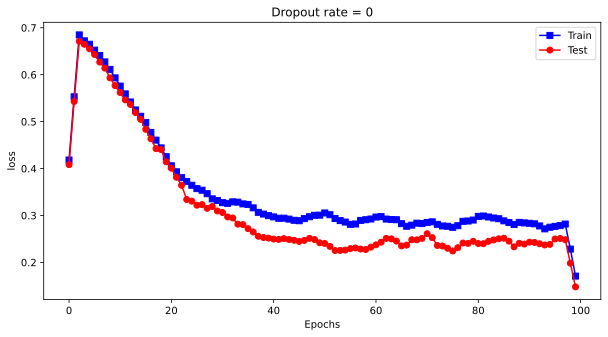

In [150]:
# plot the results
dropoutrate=0.0
fig = plt.figure(figsize=(10,5))

plt.plot(smooth(loss_train_epoch),'bs-')
plt.plot(smooth(loss_test_epoch),'ro-')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['Train','Test'])
plt.title('Dropout rate = %g'%dropoutrate)

plt.show()


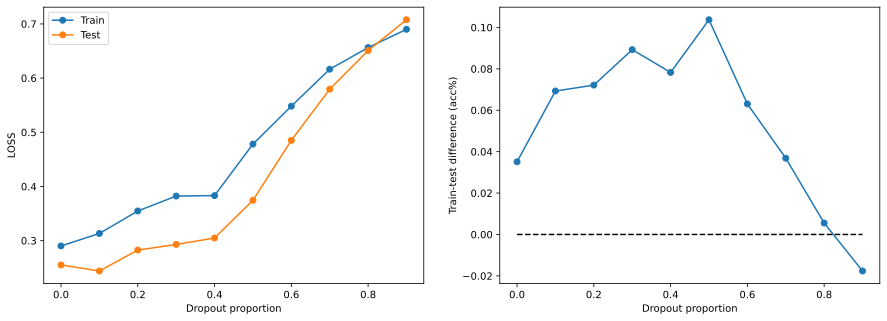

In [151]:
# plot the experiment results
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(dropoutRates,result,'o-')
ax[0].set_xlabel('Dropout proportion')
ax[0].set_ylabel('LOSS')
ax[0].legend(['Train','Test'])

ax[1].plot(dropoutRates,-np.diff(result,axis=1),'o-')
ax[1].plot([0,.9],[0,0],'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()

| 🔵 **Training Loss**      | 🟠 **Test Loss**              |
| ------------------------- | ----------------------------- |
| Slightly higher           | Lower and more stable         |
| Model is *less confident* | Model is *better generalized* |
| Regularization is working | Reduced overfitting           |


=
Graph 2: Helps find the optimal dropout that minimizes overfitting while maintaining generalization.

Probably choose dropout ≈ 0.2 or 0.3 based on the lowest test loss region.



---



A bit higher train loss + lower test loss = a well-regularized, generalizable model

iris dataset

In [37]:
import seaborn as sns

In [38]:
iris_data= sns.load_dataset('iris')

In [39]:
iris_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [24]:
from sklearn.model_selection import train_test_split

In [43]:
labels = torch.tensor((np.zeros(len(iris_data))), dtype= torch.long)
labels[np.where(iris_data['species'])=='versicolor' ]==1
labels[np.where(iris_data['species'])=='virginica' ]==2

tensor([], size=(0, 150), dtype=torch.bool)

In [49]:
labels = torch.tensor((np.zeros(len(iris_data))), dtype= torch.long)

In [62]:
labels = torch.tensor((np.zeros(len(iris_data))), dtype= torch.long)
labels[np.where(iris_data['species']=='versicolor') ]=1
labels[np.where(iris_data['species']=='virginica' )]=2

In [60]:
labels[np.where(iris_data['species']=='versicolor') ]=1

In [61]:
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

In [85]:
dataset = iris_data.drop["species"]

TypeError: 'method' object is not subscriptable

In [91]:
iris_data.drop("species",axis=1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [92]:
  X_train,x_test,y_train,y_test= train_test_split(iris_data.drop("species",axis=1), labels, test_size=0.2)


In [93]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
78,6.0,2.9,4.5,1.5
13,4.3,3.0,1.1,0.1
136,6.3,3.4,5.6,2.4
40,5.0,3.5,1.3,0.3
14,5.8,4.0,1.2,0.2
...,...,...,...,...
133,6.3,2.8,5.1,1.5
2,4.7,3.2,1.3,0.2
132,6.4,2.8,5.6,2.2
141,6.9,3.1,5.1,2.3


In [124]:
def create_train_test_dataset(dataset):
  labels = torch.tensor((np.zeros(len(dataset))), dtype= torch.long)
  X = torch.tensor(dataset.drop("species", axis=1).values, dtype=torch.float32)
  labels[np.where(dataset['species']=='versicolor' )]=1
  labels[np.where(dataset['species']=='virginica' )]=2
  X_train,x_test,y_train,y_test= train_test_split(X, labels, test_size=0.2)
  X_train_tensor= TensorDataset(X_train,y_train)
  X_test_tensor= TensorDataset(x_test,y_test)

  X_y_train_dataloader= DataLoader(X_train_tensor, batch_size=16, shuffle = True, drop_last= True)
  X_y_test_dataloader= DataLoader(X_test_tensor, batch_size=16, shuffle = True, drop_last= True)

  return X_y_train_dataloader,X_y_test_dataloader






In [125]:
class Neural_model_1(nn.Module):
  def __init__(self,dropRate=0):
    super().__init__()


    self.layer1= nn.Linear(4,64)
    self.hidden= nn.Linear(64,128)
    self.output= nn.Linear(128,3)

    self.dropRate= dropRate
  def forward(self,x):
      x= torch.relu(self.layer1(x))
      x= F.dropout(x, p=self.dropRate, training= self.training)
      x= torch.relu(self.hidden(x))
      x= F.dropout(x, p=self.dropRate, training= self.training)
      x= self.output(x)

      return x




In [126]:
def create_model(dropRate=0):
  model = Neural_model_1(dropRate)
  loss= nn.CrossEntropyLoss()
  optimizer= torch.optim.Adam(model.parameters(), lr=0.001)
  return model, loss, optimizer

In [136]:
def training(dataset,dropRate=0):
  X_y_train_dataloader,X_y_test_dataloader=create_train_test_dataset(dataset)
  model, loss, optimizer=create_model(dropRate)
  nepoch = 200
  train_loss=[]
  test_loss= []

  for epoch in range(nepoch):
    model.train()
    loss_fn=0
    loss_train_batch=[]
    loss_test_batch=[]
    for x,y in X_y_train_dataloader:

        yhat= model(x)
        loss_fn= loss(yhat,y)

        optimizer.zero_grad()
        loss_fn.backward()
        optimizer.step()

        loss_train_batch.append(loss_fn.item())


    train_loss.append(np.mean(loss_train_batch))

    model.eval()
    with torch.no_grad():
      for x,y in X_y_test_dataloader:

          yhat= model(x)
          loss_fn= loss(yhat,y)
          loss_test_batch.append(loss_fn.item())

      test_loss.append(np.mean(loss_test_batch))

  return train_loss,test_loss





In [133]:
import seaborn as sns
iris_data= sns.load_dataset('iris')
def evaluation():
  dropoutRate= np.arange(10)/10
  result = np.zeros((len(dropoutRate),2))
  for i,rate in enumerate(dropoutRate):
    train_loss,test_loss=training(iris_data,rate)
    result[i,0]= np.mean(train_loss)
    result[i,1]= np.mean(test_loss)
  return result,dropoutRate


when dropout is zero

In [111]:
import seaborn as sns
iris_data= sns.load_dataset('iris')
def evaluation_no_dropout():
  dropoutRate= 0
  train_loss,test_loss=training(iris_data)
  return train_loss,test_loss,dropoutRate


In [138]:
train_loss,test_loss,dropoutRate=evaluation_no_dropout()

In [140]:
result,dropoutRate=evaluation()

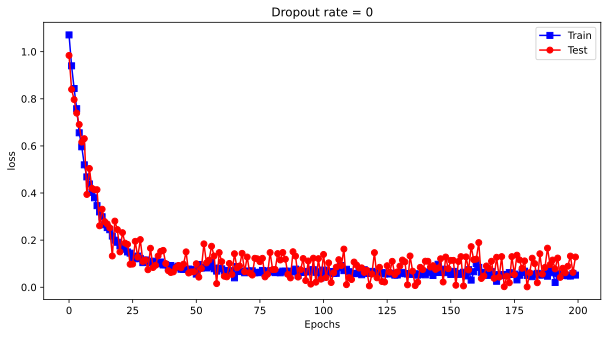

In [145]:
# plot the results
dropoutrate=0.0
fig = plt.figure(figsize=(10,5))

plt.plot(train_loss,'bs-')
plt.plot(test_loss,'ro-')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['Train','Test'])
plt.title('Dropout rate = %g'%dropoutrate)

plt.show()

In [89]:
result,dropoutRate=evaluation()

In [90]:
result

array([[0.05555332, 0.0609659 ],
       [0.05246326, 0.10143964],
       [0.06402022, 0.19860998],
       [0.086914  , 0.01668597],
       [0.05914728, 0.17137419],
       [0.11684015, 0.07855263],
       [0.13458202, 0.16667271],
       [0.2295943 , 0.13323493],
       [0.44783174, 0.37892625],
       [0.57327687, 0.77605891]])

In [91]:
def smooth(x,k=5):
  return np.convolve(x,np.zeros(k)/k, mode='same')


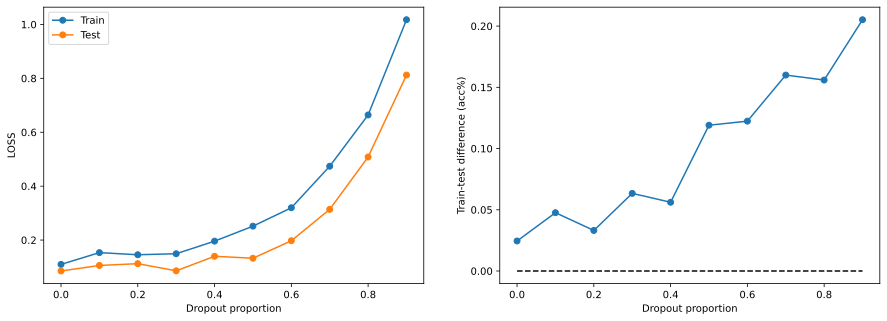

In [141]:
# plot the experiment results
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(dropoutRate,result,'o-')
ax[0].set_xlabel('Dropout proportion')
ax[0].set_ylabel('LOSS')
ax[0].legend(['Train','Test'])

ax[1].plot(dropoutRate,-np.diff(result,axis=1),'o-')
ax[1].plot([0,.9],[0,0],'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()